# 머신러닝
1. 지도학습 : 정답이 있음
- 분류 (Classification), 회귀(Regression)

2. 비지도 학습 : 정답이 없음
- 군집 (Clustering)

3. 강화 학습

---

# 딥러닝 : 신경망

---

# EDA (탐색적 데이터 분석) - 모델 - 추론
1. 데이터 전처리
- 이상치 제거 (대처), 결측치 제거 (대처), 새로운 피처 생성
- 상관지수를 통한 적절한 변수 선택

2. 적절한 모델 선택
3. 평가
4. 추론


##### 파이프라인 : 일련의 과정들을 자동화

In [ ]:
# y = ax + b
# y 정답
# x 입력값
# a 기울기
# b 절편 (bias) : 보정하기 위한, 즉 미세조정하는 의미

In [5]:
# %conda install scikit-learn

In [9]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# 데이터 준비
x = np.array([1,2,3,4, 5]).reshape(-1, 1) # 공부 시간
y = np.array([50,60,65,70,72])
print(x.shape, y.shape)

# 모델 생성
model = LinearRegression()

# 모델 학습
model.fit(x, y)

# 학습 결과
print(f'기울기 : {model.coef_}')
print(f'절편 : {model.intercept_}')

new_x = np.array([5, 10, 3.5, 20]).reshape(-1, 1)
print(f'새로운 데이터 x에 대한 모델이 예측한 값 : {model.predict(new_x)}')

(5, 1) (5,)
기울기 : [5.4]
절편 : 47.199999999999996
새로운 데이터 x에 대한 모델이 예측한 값 : [ 74.2 101.2  66.1 155.2]


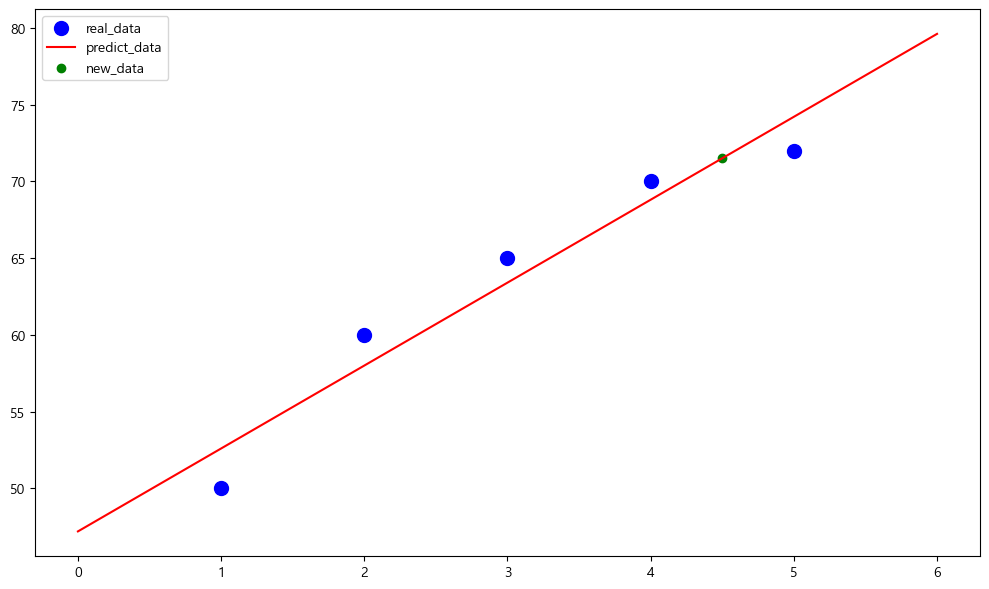

In [33]:
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(x, y, color = 'blue', s = 100, label = 'real_data')

# 머신러닝이 예측한 예측 직선 (스캐터를 매우 촘촘히 사용할 것)
x_line = np.linspace(0,6,100).reshape(-1, 1)
y_line = model.predict(x_line)

ax.plot(x_line, y_line, color='red', label='predict_data')

# 새로운 예측값
new_x = np.array([[4.5]])
new_y = model.predict(new_x)

ax.scatter(new_x, new_y, color = 'green', label='new_data')

plt.legend()
plt.tight_layout()
plt.show()

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.dates as mdates

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [34]:
# age	나이
# sex	성별
# bmi	체질량지수 (Body Mass Index)
# bp	평균 혈압
# s1	총 혈청 콜레스테롤
# s2	저밀도 지단백 (LDL)
# s3	고밀도 지단백 (HDL)
# s4	총 콜레스테롤 / HDL 비율
# s5	혈청 중성지방의 로그값
# s6	혈당 수치
# 모든 컬럼은 평균 0, 표준편차 1로 정규화(standardized) 되어 있음

In [29]:
iris = sns.load_dataset('iris')
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [35]:
# 정규화 :각 원소를 평균으로 뺀 값을 표준편차로 나눔

data = np.array([10, 20, 30])
data.mean(), data.std()

standard_data = (data - data.mean()) / data.std()
standard_data.mean() , round(standard_data.std(),1)

(np.float64(0.0), np.float64(1.0))

(array([ 7., 42., 68., 51., 31., 19., 12.,  7.,  3.,  4.]),
 array([-1.88154652, -1.34418508, -0.80682363, -0.26946218,  0.26789926,
         0.80526071,  1.34262215,  1.8799836 ,  2.41734504,  2.95470649,
         3.49206794]),
 <BarContainer object of 10 artists>)

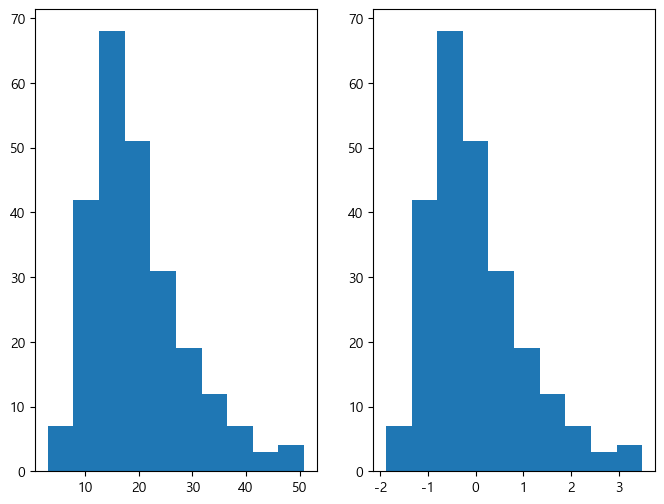

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
tips = sns.load_dataset('tips')

data = tips['total_bill'].values
fig, axes = plt.subplots(1,2,figsize=(8,6))
axes[0].hist(data)

data_mean = data.mean()
data_std = data.std()
standard_data = (data-data_mean) / data_std
axes[1].hist(standard_data)

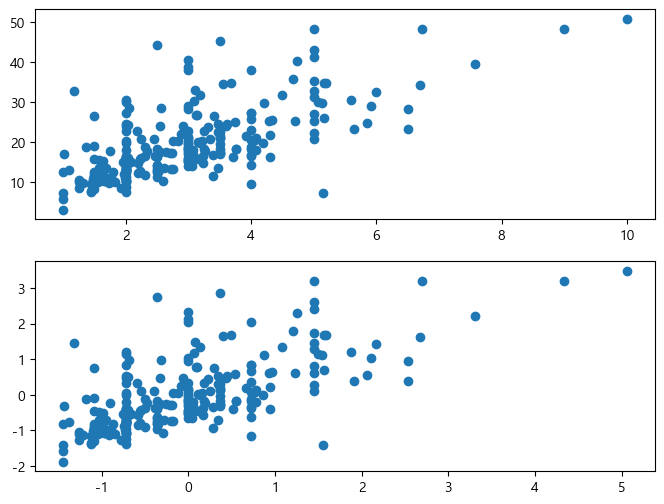

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
tips = sns.load_dataset('tips')
fig, axes = plt.subplots(2,1,figsize=(8,6))
axes[0].scatter(tips['tip'],tips['total_bill'])

standard_tip = (tips['tip'] - tips['tip'].mean()) / tips['tip'].std()
standard_total_bill = (tips['total_bill'] - tips['total_bill'].mean()) / tips['total_bill'].std()
axes[1].scatter(standard_tip,standard_total_bill)

In [40]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
df = load_diabetes(as_frame=True).frame
df.head()
x = df[['bmi']]
y = df['target']
print(x.shape, y.shape)

# y = ax + b
# 1 모델 선택
model = LinearRegression()
# 2. 모델 학습
model.fit(x,y)
# 3. 모델 예측(추론)
predicted = model.predict(np.array([[0.061696]]) )
print(predicted)

(442, 1) (442,)
[210.70984199]


c:\Users\Playdata\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [41]:
import random
random_index = random.sample(range(442),442)  # 0 ~ 441  섞음
x2 =  x['bmi'][random_index]
y2 =  y[random_index]

split_count = int(len(x['bmi'])*0.8)

x2_train = x2[:split_count]
y2_train = y2[:split_count]

x2_test = x2[split_count : ]
y2_test = y2[split_count : ]

model = LinearRegression()

model.fit(x2_train.to_numpy().reshape(-1,1),y2_train)  # 모델 학습

# 예측
predicted =  model.predict(x2_test.to_numpy().reshape(-1,1))

predicted[:5],  y2_test[:5].to_numpy()

from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
mean_absolute_error(y2_test,predicted), mean_squared_error(y2_test,predicted), r2_score(y2_test,predicted)

(51.10147740627138, 3808.8536974273334, 0.4358223715381786)

In [42]:
# 데이터 (X, Y)
# 데이터를 섞어서 분할(학습용과 테스트용)
# 적절한 모델 선택
# 학습->학습용 데이터
# 추론(예측) ->테스트용 데이터
# 평가 : 테스트용데이터의 실제 정답 vs 모델이 테스트용 데이터로 예측한값의 오차

In [ ]:
# # train_test_split
# from sklearn.model_selection import train_test_split
# X = df[['bmi',	'bp']].to_numpy().reshape(-1,1)
# y = df['target'].to_numpy()
# X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=2,random_state=42)

# model = LinearRegression()
# # 학습
# # 예측
# # 평가

ValueError: Found input variables with inconsistent numbers of samples: [884, 442]